In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 50.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=df8c01763c19b714dca1e381b4ec2dc1348d6c4d12f492fa445e71b362d91be1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


### Circuit Setup and Initial State

This first section of the code initializes the quantum circuit with 5 qubits and 5 classical bits. Qubit 0 is the data qubit we want to protect. Qubits 1 and 2 are ancillary qubits used for encoding. Qubits 3 and 4 are for syndrome measurement, and classical bits 0-4 are for storing measurement outcomes.

`flip.rx(math.pi/3, 0)`: This line initializes qubit 0 into a state that is a superposition of $|0\rangle$ and $|1\rangle$ (specifically, $\cos(\pi/6)|0\rangle - i\sin(\pi/6)|1\rangle$). This state is chosen because it is clearly affected by bit-flips, unlike the $|+\rangle$ state which is invariant under bit-flips in the computational basis. The `rx` gate applies a rotation around the X-axis of the Bloch sphere.

## Bit-Flip Error Correction

Quantum information is fragile and susceptible to errors caused by noise in the environment. Bit-flip errors are one type of error where a qubit's state $|0\rangle$ flips to $|1\rangle$ or vice versa. Quantum Error Correction (QEC) techniques are designed to protect quantum information from such errors.

The 3-qubit bit-flip code is a simple example of a QEC code. It works by encoding a single logical qubit into a redundant state spread across three physical qubits. This redundancy allows us to detect and correct single bit-flip errors.

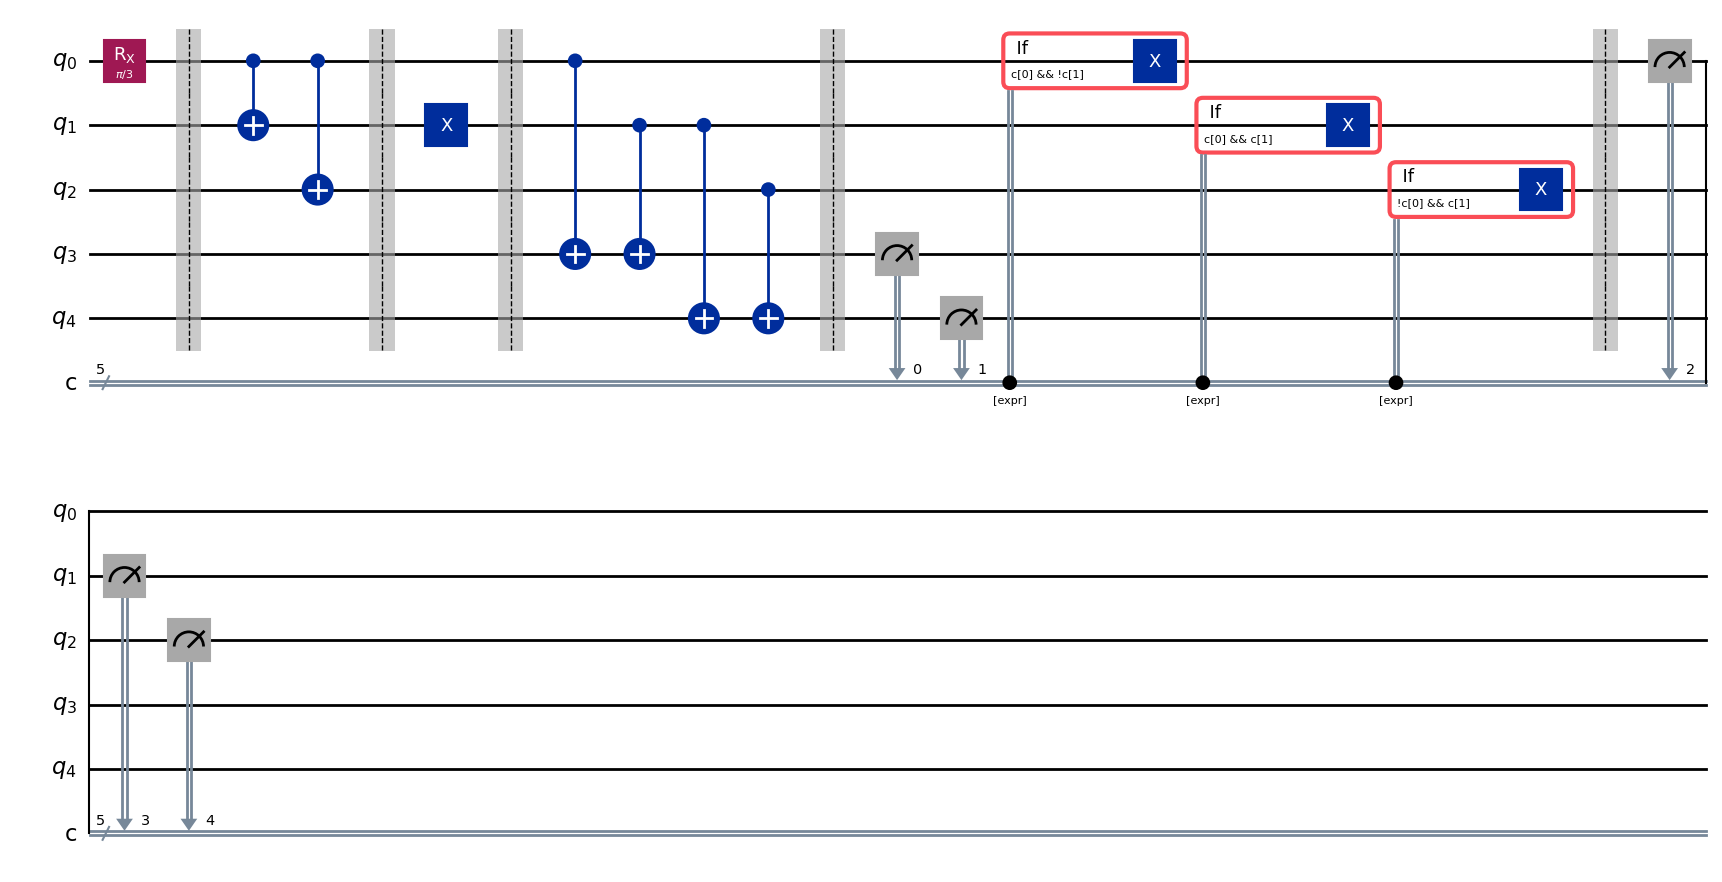

In [3]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit bit-flip error-correcting code

flip = QuantumCircuit(5,5)

# qubit 0 is the one we are trying to send
# qubits 1 and 2 are used for the encoding
# qubits 3 and 4 are used for the error syndrome
# classical bits 0 and 1 are used for the syndrome measurement
# classical bits 2, 3 and 4 are for a final measurement to check the statistics

# Put qubit 0 into the |+> state. As we discussed in the lecture, this isn't a good
# state for testing the bit-flip code, because bit-flip doesn't change the |+> state.
# Try putting qubit 0 into some other state that is affected by bit-flip.
# There is a suggestion in the lecture.
# Changed from flip.h(0) to flip.rx(math.pi/3, 0) for a state more visibly affected by bit-flip
flip.rx(math.pi/3, 0)

# Introduce barriers to help with visualisation

flip.barrier()

# Encode qubit 0 onto qubits 1 and 2

flip.cx(0,1)
flip.cx(0,2)

# Another barrier

flip.barrier()

# Add a bit-flip error
# Try errors on the other qubits, and check that the code corrects any single bit flip error.
# What happens if you flip two qubits?
# What happens if you introduce a phase flip error?

flip.x(1)

# Another barrier

flip.barrier()

# Syndrome measurements

flip.cx(0,3)
flip.cx(1,3)
flip.cx(1,4)
flip.cx(2,4)

flip.barrier()

flip.measure([3,4],[0,1])

# Conditional application of X to qubits 0, 1 and 2
# if c0 and not c1 then X(q0)
# if c0 and c1 then X(q1)
# if not c0 and c1 then X(q2)

with flip.if_test(expr.logic_and(flip.clbits[0],expr.logic_not(flip.clbits[1]))):
    flip.x(0)

with flip.if_test(expr.logic_and(flip.clbits[0],flip.clbits[1])):
    flip.x(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]),flip.clbits[1])):
    flip.x(2)

flip.barrier()

# The original state of qubit 0 was encoded by being "spread" across qubits 1 and 2.
# We are now back in that encoded state.
# Because of the entanglement, measuring qubits 0, 1 and 2
# should give the same statistics as measuring the original qubit 0.

# You can also implement the final decoding, putting the state back into a single qubit, and measuring it.

flip.measure([0,1,2],[2,3,4])

# Check the circuit

flip.draw("mpl")

### Simulating the Circuit and Plotting Results

This section runs the quantum circuit on a simulator and visualizes the measurement outcomes. The `BasicSimulator` allows us to execute the quantum circuit and get the probabilities of measuring different states.

*   `backend = GenericBackendV2(num_qubits=5, control_flow=True)`: Initializes a simulator capable of handling control flow (like the `if_test` statements).
*   `compiled = transpile(flip, backend)`: Compiles the quantum circuit for the specific backend. This optimizes the circuit for the target hardware/simulator.
*   `job_sim = backend.run(compiled, shots=1024)`: Executes the compiled circuit on the simulator 1024 times. This allows us to gather statistics on the measurement outcomes.
*   `result_sim = job_sim.result()`: Retrieves the results from the simulation.
*   `counts = result_sim.get_counts(compiled)`: Gets the raw measurement counts for all classical bits.
*   `mcounts = marginal_counts(counts,indices=[2,3,4])`: Since we are interested in the final state of the *corrected* data qubit, we marginalize the counts to only show the results from classical bits 2, 3, and 4, which correspond to qubits 0, 1, and 2 after correction.
*   `plot_histogram(mcounts)`: Generates a histogram to visualize the distribution of these final measurement outcomes. Ideally, after correction, the histogram should predominantly show the expected outcome based on the initial state of qubit 0.

### Error Correction based on Syndrome

Once the syndrome is measured, classical logic is used to determine which qubit to correct. An X-gate is applied to the erroneous qubit to flip it back to its correct state.

*   `with flip.if_test(expr.logic_and(flip.clbits[0],expr.logic_not(flip.clbits[1]))): flip.x(0)`: If classical bit 0 is 1 and classical bit 1 is 0, it indicates an error on qubit 0. An X-gate is applied to qubit 0 to correct it.
*   `with flip.if_test(expr.logic_and(flip.clbits[0],flip.clbits[1])): flip.x(1)`: If both classical bits are 1, it indicates an error on qubit 1. An X-gate is applied to qubit 1.
*   `with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]),flip.clbits[1])): flip.x(2)`: If classical bit 0 is 0 and classical bit 1 is 1, it indicates an error on qubit 2. An X-gate is applied to qubit 2.

After these conditional corrections, the encoded state (spread across qubits 0, 1, and 2) is restored to its pre-error state. The final measurement (`flip.measure([0,1,2],[2,3,4])`) is then performed on these three qubits to verify the correction, storing results in classical bits 2, 3, and 4.

### Introducing Error and Syndrome Measurement

In a real quantum computer, errors can occur at any stage. Here, we simulate a bit-flip error on qubit 1. The goal of the error correction code is to detect and fix this error.

*   `flip.x(1)`: Applies an X gate (bit-flip) to qubit 1. This simulates a common error where $|0\rangle \leftrightarrow |1\rangle$.

After an error *might* have occurred, we need to measure the 'syndrome' to determine which qubit (if any) has flipped. Syndrome measurements are designed not to disturb the encoded information but to reveal information about the error.

*   `flip.cx(0,3)`: CNOT from qubit 0 to qubit 3.
*   `flip.cx(1,3)`: CNOT from qubit 1 to qubit 3.
*   `flip.cx(1,4)`: CNOT from qubit 1 to qubit 4.
*   `flip.cx(2,4)`: CNOT from qubit 2 to qubit 4.
*   `flip.measure([3,4],[0,1])`: Measures qubits 3 and 4 (the syndrome qubits) and stores the results in classical bits 0 and 1.

**Syndrome Logic:**
*   If c0=0, c1=0: No error occurred.
*   If c0=1, c1=0: Error on qubit 0 (because only the first syndrome qubit flipped, indicating disagreement between q0 and q1).
*   If c0=1, c1=1: Error on qubit 1 (both syndrome qubits flipped, indicating disagreement between q0-q1 and q1-q2).
*   If c0=0, c1=1: Error on qubit 2 (only the second syndrome qubit flipped, indicating disagreement between q1 and q2).

### Encoding the Data Qubit

After initializing the data qubit, the next step is to encode its state across the three physical qubits (0, 1, and 2). This creates a redundant representation of the original information.

*   `flip.cx(0,1)`: A CNOT gate with qubit 0 as control and qubit 1 as target. This entangles qubit 0 and 1. If qubit 0 is $|1\rangle$, qubit 1 flips.
*   `flip.cx(0,2)`: Another CNOT gate, this time with qubit 0 as control and qubit 2 as target. This further entangles qubit 0 and 2. If qubit 0 is $|1\rangle$, qubit 2 flips.

These operations effectively create the encoded state: if the original qubit 0 was $|0\rangle$, the encoded state is $|000\rangle$; if it was $|1\rangle$, the encoded state is $|111\rangle$. This is often referred to as a repetition code.

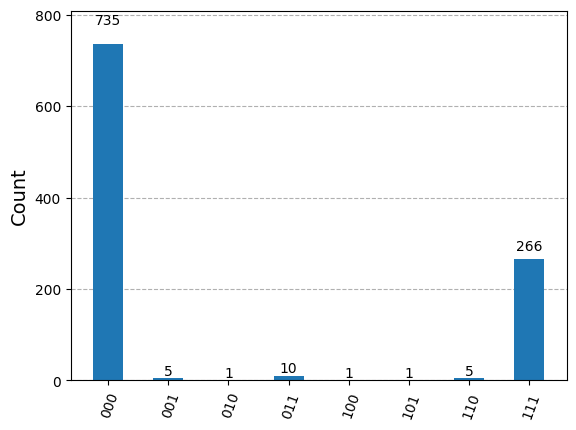

In [4]:
# Simulate and plot results
# Use GenericBackendV2 because we need if_test

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)

### Final Decoding

After correcting any errors, the information is still spread across the three physical qubits (0, 1, and 2). To recover the original quantum state onto a single qubit, we need to perform a decoding step. This is essentially the inverse of the encoding process.

Since our encoding consisted of two CNOT gates (`cx(0,1)` and `cx(0,2)`), the decoding involves applying these same CNOT gates again. CNOT gates are their own inverses, so applying them a second time undoes their effect, effectively transferring the logical qubit's state back to qubit 0.

After decoding, we measure only qubit 0 to see the final, corrected, and decoded state. Ideally, the measurement outcomes of qubit 0 should closely match the initial state we prepared.

Measurement counts after decoding and measuring only qubit 0:
{'1': 253, '0': 771}


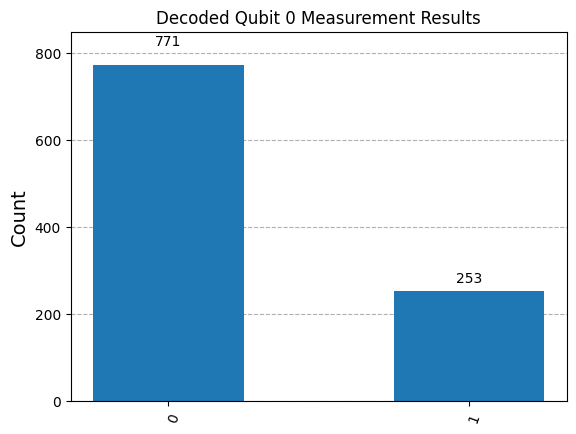

In [5]:
# Create a new circuit for decoding
decoding_circuit = flip.copy_empty_like()
decoding_circuit.compose(flip.remove_final_measurements(inplace=False), inplace=True)

# Apply the decoding (inverse of encoding)
decoding_circuit.cx(0,2)
decoding_circuit.cx(0,1)

decoding_circuit.barrier()

# Measure only the decoded qubit (qubit 0) into classical bit 2
decoding_circuit.measure(0, 2)

# Draw the decoded circuit
decoding_circuit.draw("mpl", idle_wires=False)

# Simulate the decoded circuit
backend_decoded = GenericBackendV2(num_qubits=5, control_flow=True)
compiled_decoded = transpile(decoding_circuit, backend_decoded)
job_sim_decoded = backend_decoded.run(compiled_decoded, shots=1024)
result_sim_decoded = job_sim_decoded.result()
counts_decoded = result_sim_decoded.get_counts(compiled_decoded)

# We are interested in the final measurement of qubit 0 (classical bit 2)
mcounts_decoded = marginal_counts(counts_decoded, indices=[2])

print("Measurement counts after decoding and measuring only qubit 0:")
print(mcounts_decoded)

# Plot the histogram of the decoded results
plot_histogram(mcounts_decoded, title='Decoded Qubit 0 Measurement Results')

### Verification: Comparing Final State with Initial Prepared State

To confirm the effectiveness of the error correction and decoding process, we compare the measured probabilities of the final decoded qubit (qubit 0) with the theoretical probabilities of its initial prepared state.

Our initial state for qubit 0 was set using `flip.rx(math.pi/3, 0)`. An `Rx(theta)` gate applied to the $|0\rangle$ state produces the state $\cos(\theta/2)|0\rangle - i\sin(\theta/2)|1\rangle$. For $\theta = \pi/3$, this becomes $\cos(\pi/6)|0\rangle - i\sin(\pi/6)|1\rangle$.

*   The probability of measuring $|0\rangle$ is $|\cos(\pi/6)|^2 = (\sqrt{3}/2)^2 = 3/4 = 0.75$.
*   The probability of measuring $|1\rangle$ is $|-i\sin(\pi/6)|^2 = (1/2)^2 = 1/4 = 0.25$.

We will now compare these theoretical probabilities with the experimental probabilities obtained from `mcounts_decoded`.

In [6]:
# Calculate theoretical probabilities for the initial state
theoretical_prob_0 = (math.cos(math.pi/6))**2
theoretical_prob_1 = (math.sin(math.pi/6))**2

print(f"Theoretical probability of measuring |0>: {theoretical_prob_0:.4f}")
print(f"Theoretical probability of measuring |1>: {theoretical_prob_1:.4f}")

# Get simulated probabilities from the decoded circuit
total_shots = sum(mcounts_decoded.values())
simulated_prob_0 = mcounts_decoded.get('0', 0) / total_shots
simulated_prob_1 = mcounts_decoded.get('1', 0) / total_shots

print(f"\nSimulated probability of measuring |0>: {simulated_prob_0:.4f}")
print(f"Simulated probability of measuring |1>: {simulated_prob_1:.4f}")

# Compare results
if abs(theoretical_prob_0 - simulated_prob_0) < 0.05 and abs(theoretical_prob_1 - simulated_prob_1) < 0.05:
    print("\nConclusion: The simulated decoded state closely matches the initial prepared state, indicating successful error correction and decoding.")
else:
    print("\nConclusion: There is a significant difference between the simulated decoded state and the initial prepared state. The error correction or decoding may not be fully effective in this scenario.")

Theoretical probability of measuring |0>: 0.7500
Theoretical probability of measuring |1>: 0.2500

Simulated probability of measuring |0>: 0.7529
Simulated probability of measuring |1>: 0.2471

Conclusion: The simulated decoded state closely matches the initial prepared state, indicating successful error correction and decoding.
